In [1]:
# ШАГ 1. Импорты библиотек
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

In [2]:
# ШАГ 2. Фиксируем seed и определяем устройство
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("SEED:", SEED)
print("DEVICE:", DEVICE)

# ШАГ 3. Настраиваем пути к файлам и папкам
BASE_DIR = Path(".")
DATA_PATH = BASE_DIR / "S12-hw-dataset.csv"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH.resolve())
print("ARTIFACTS_DIR:", ARTIFACTS_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())

SEED: 42
DEVICE: cuda
DATA_PATH: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW12\S12-hw-dataset.csv
ARTIFACTS_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW12\artifacts
FIGURES_DIR: C:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW12\artifacts\figures


In [3]:
# ШАГ 4. Реализуем функции метрик
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), eps, None))) * 100

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.clip(np.abs(y_true) + np.abs(y_pred), eps, None)
    return np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100

def calc_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }

In [4]:
# ШАГ 5. Загружаем датасет
df = pd.read_csv(DATA_PATH)

print("Первые строки датасета:")
display(df.head())

print("\nКолонки:")
print(df.columns.tolist())

Первые строки датасета:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62



Колонки:
['date', 'target']


In [5]:
# ШАГ 6. Приводим date к datetime и сортируем по времени
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Тип date:", df["date"].dtype)
print("Данные после сортировки:")
display(df.head())

Тип date: datetime64[us]
Данные после сортировки:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [6]:
# ШАГ 7. Sanity-check данных
print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "->", df["date"].max())

print("\nЧисло пропусков по колонкам:")
display(df.isna().sum())

print("\nОписание target:")
display(df["target"].describe())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00

Число пропусков по колонкам:


date      0
target    0
dtype: int64


Описание target:


count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

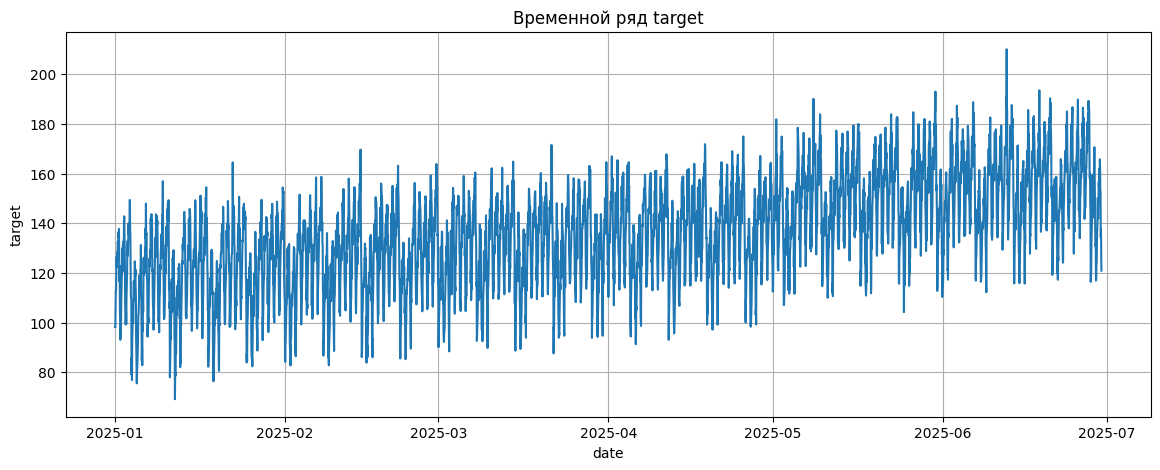

In [7]:
# ШАГ 8. Строим базовый график временного ряда
plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["target"])
plt.title("Временной ряд target")
plt.xlabel("date")
plt.ylabel("target")
plt.grid(True)
plt.show()

## Краткий комментарий по данным

Временной ряд демонстрирует общий восходящий тренд: значения `target` постепенно увеличиваются со временем, что указывает на нестационарность ряда. При этом на графике хорошо заметны регулярные колебания, что может свидетельствовать о наличии сезонности (вероятно, краткосрочной, например, недельной).

Ряд достаточно шумный: присутствуют частые локальные колебания вверх и вниз, а также отдельные выбросы (как в сторону увеличения, так и снижения значений). Это может усложнять задачу прогноза, особенно для простых моделей.

В целом, ряд сочетает в себе тренд + сезонность + шум, поэтому для него важно использовать корректную временную валидацию и признаки, учитывающие прошлые значения (лаги и rolling-статистики).

In [8]:
# ШАГ 9. Делаем temporal split: train / val / test
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Размер train:", len(train_df))
print("Размер val:", len(val_df))
print("Размер test:", len(test_df))

print("\nГраницы split:")
print("train:", train_df["date"].min(), "->", train_df["date"].max())
print("val  :", val_df["date"].min(), "->", val_df["date"].max())
print("test :", test_df["date"].min(), "->", test_df["date"].max())

Размер train: 3024
Размер val: 648
Размер test: 648

Границы split:
train: 2025-01-01 00:00:00 -> 2025-05-06 23:00:00
val  : 2025-05-07 00:00:00 -> 2025-06-02 23:00:00
test : 2025-06-03 00:00:00 -> 2025-06-29 23:00:00


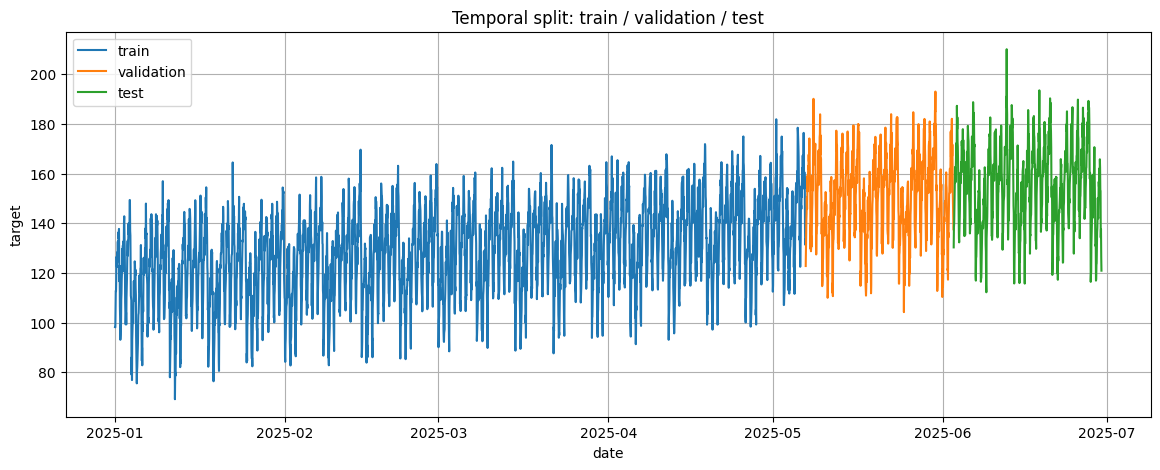

График сохранён: artifacts\figures\series_split.png


In [9]:
# ШАГ 10. Визуализируем split на одном графике
plt.figure(figsize=(14, 5))

plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")

plt.title("Temporal split: train / validation / test")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.grid(True)

split_fig_path = FIGURES_DIR / "series_split.png"
plt.savefig(split_fig_path, bbox_inches="tight")
plt.show()

print("График сохранён:", split_fig_path)

## Почему random split здесь некорректен

Для временных рядов нельзя случайно перемешивать строки, потому что тогда модель может обучаться на будущих наблюдениях и проверяться на прошлых. Это создаёт утечку информации и делает оценку слишком оптимистичной. В реальной задаче прогноз всегда строится только по прошлому, поэтому разбиение должно быть строго хронологическим.

In [10]:
# ШАГ 11. Строим lag-, rolling- и календарные признаки
df_feat = df.copy()

df_feat["lag_1"] = df_feat["target"].shift(1)
df_feat["lag_7"] = df_feat["target"].shift(7)
df_feat["lag_14"] = df_feat["target"].shift(14)

df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(window=7).mean()
df_feat["rolling_std_7"] = df_feat["target"].shift(1).rolling(window=7).std()

df_feat["day_of_week"] = df_feat["date"].dt.dayofweek
df_feat["day_of_month"] = df_feat["date"].dt.day
df_feat["month"] = df_feat["date"].dt.month

print("Первые строки с признаками:")
display(df_feat.head(20))

Первые строки с признаками:


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day_of_month,month
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,2,1,1
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,NaN,NaN,2,1,1
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,NaN,NaN,2,1,1
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,NaN,NaN,2,1,1
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,NaN,NaN,2,1,1
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,NaN,NaN,2,1,1
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,NaN,NaN,2,1,1
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,2,1,1
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,2,1,1
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,2,1,1


In [11]:
# ШАГ 12. Удаляем строки, где признаки ещё не успели сформироваться
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "day_of_month",
    "month",
]

df_feat = df_feat.dropna().reset_index(drop=True)

print("Размер после dropna:", len(df_feat))
display(df_feat.head())

Размер после dropna: 4306


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,day_of_month,month
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,1,1
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,1,1
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,1,1
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,1,1
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,1,1


In [12]:
# ШАГ 13. Повторяем temporal split уже для таблицы с признаками
n_feat = len(df_feat)

train_end_feat = int(n_feat * 0.70)
val_end_feat = int(n_feat * 0.85)

train_feat = df_feat.iloc[:train_end_feat].copy()
val_feat = df_feat.iloc[train_end_feat:val_end_feat].copy()
test_feat = df_feat.iloc[val_end_feat:].copy()

print("train_feat:", len(train_feat))
print("val_feat:", len(val_feat))
print("test_feat:", len(test_feat))

train_feat: 3014
val_feat: 646
test_feat: 646


In [13]:
# ШАГ 14. Готовим данные для Ridge на признаках
X_train = train_feat[feature_cols].copy()
y_train = train_feat["target"].copy()

X_val = val_feat[feature_cols].copy()
y_val = val_feat["target"].copy()

X_test = test_feat[feature_cols].copy()
y_test = test_feat["target"].copy()

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

print("Форма X_train:", X_train_scaled.shape)
print("Форма y_train:", y_train.shape)

Форма X_train: (3014, 8)
Форма y_train: (3014,)


In [14]:
# ШАГ 15. Создаём список для записи результатов экспериментов
runs = []

def add_run(
    experiment_id,
    task,
    dataset,
    seed,
    split_summary,
    window_size,
    horizon,
    model_summary,
    features_summary,
    scaler,
    optimizer,
    lr,
    epochs_trained,
    best_val_mae,
    best_val_rmse,
    best_val_mape,
    test_mae,
    test_rmse,
    test_mape,
    notes
):
    runs.append({
        "experiment_id": experiment_id,
        "task": task,
        "dataset": dataset,
        "seed": seed,
        "split_summary": split_summary,
        "window_size": window_size,
        "horizon": horizon,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": best_val_mae,
        "best_val_rmse": best_val_rmse,
        "best_val_mape": best_val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes,
    })

In [15]:
# ШАГ 16. Эксперимент B1: naive-last

val_pred_b1 = val_feat["lag_1"].values
val_true_b1 = val_feat["target"].values

metrics_b1_val = calc_metrics(val_true_b1, val_pred_b1)
print("B1 validation metrics:", metrics_b1_val)

add_run(
    experiment_id="B1",
    task="forecasting",
    dataset="S12-hw-dataset.csv",
    seed=SEED,
    split_summary="70/15/15 temporal split",
    window_size="",
    horizon=1,
    model_summary="naive-last",
    features_summary="last observed value",
    scaler="no",
    optimizer="",
    lr="",
    epochs_trained="",
    best_val_mae=metrics_b1_val["mae"],
    best_val_rmse=metrics_b1_val["rmse"],
    best_val_mape=metrics_b1_val["mape"],
    test_mae="",
    test_rmse="",
    test_mape="",
    notes="Validation only"
)

B1 validation metrics: {'mae': 6.4434055727554185, 'rmse': 8.20353204909296, 'mape': np.float64(4.394593960122376), 'smape': np.float64(4.360591543836804)}


In [16]:
# ШАГ 17. Эксперимент B2: moving-average
val_pred_b2 = val_feat["rolling_mean_7"].values
val_true_b2 = val_feat["target"].values

metrics_b2_val = calc_metrics(val_true_b2, val_pred_b2)
print("B2 validation metrics:", metrics_b2_val)

add_run(
    experiment_id="B2",
    task="forecasting",
    dataset="S12-hw-dataset.csv",
    seed=SEED,
    split_summary="70/15/15 temporal split",
    window_size=7,
    horizon=1,
    model_summary="moving-average",
    features_summary="rolling_mean_7",
    scaler="no",
    optimizer="",
    lr="",
    epochs_trained="",
    best_val_mae=metrics_b2_val["mae"],
    best_val_rmse=metrics_b2_val["rmse"],
    best_val_mape=metrics_b2_val["mape"],
    test_mae="",
    test_rmse="",
    test_mape="",
    notes="Validation only"
)

B2 validation metrics: {'mae': 12.723717381689518, 'rmse': 15.236325500475134, 'mape': np.float64(8.82877937382802), 'smape': np.float64(8.626416548455037)}


In [17]:
# ШАГ 18. Эксперимент B3: Ridge на lag/rolling/calendar признаках
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

val_pred_b3 = ridge_model.predict(X_val_scaled)
val_true_b3 = y_val.values

metrics_b3_val = calc_metrics(val_true_b3, val_pred_b3)
print("B3 validation metrics:", metrics_b3_val)

add_run(
    experiment_id="B3",
    task="forecasting",
    dataset="S12-hw-dataset.csv",
    seed=SEED,
    split_summary="70/15/15 temporal split",
    window_size="",
    horizon=1,
    model_summary="Ridge(alpha=1.0)",
    features_summary=", ".join(feature_cols),
    scaler="StandardScaler fitted on train only",
    optimizer="",
    lr="",
    epochs_trained="",
    best_val_mae=metrics_b3_val["mae"],
    best_val_rmse=metrics_b3_val["rmse"],
    best_val_mape=metrics_b3_val["mape"],
    test_mae="",
    test_rmse="",
    test_mape="",
    notes="Validation only"
)

B3 validation metrics: {'mae': 6.341245180091855, 'rmse': 7.935198901390999, 'mape': np.float64(4.2456552799841925), 'smape': np.float64(4.292060783915208)}


In [18]:
# ШАГ 19. Готовим временной ряд для GRU
series_df = df[["date", "target"]].copy().reset_index(drop=True)

n_series = len(series_df)
train_end_series = int(n_series * 0.70)
val_end_series = int(n_series * 0.85)

series_train = series_df.iloc[:train_end_series].copy()
series_val = series_df.iloc[train_end_series:val_end_series].copy()
series_test = series_df.iloc[val_end_series:].copy()

print("series_train:", len(series_train))
print("series_val:", len(series_val))
print("series_test:", len(series_test))

series_train: 3024
series_val: 648
series_test: 648


In [19]:
# ШАГ 20. Масштабируем target для GRU
target_scaler = StandardScaler()

train_target_scaled = target_scaler.fit_transform(series_train[["target"]]).flatten()
val_target_scaled = target_scaler.transform(series_val[["target"]]).flatten()
test_target_scaled = target_scaler.transform(series_test[["target"]]).flatten()

print("Пример масштабированных train-значений:")
print(train_target_scaled[:5])

Пример масштабированных train-значений:
[-1.62679933 -1.6305869  -1.2718506  -0.83303441 -0.84331493]


In [20]:
# ШАГ 21. Функция создания окон фиксированной длины
def create_windows(values, window_size):
    X, y = [], []
    for i in range(window_size, len(values)):
        X.append(values[i - window_size:i])
        y.append(values[i])
    return np.array(X), np.array(y)

In [21]:
# ШАГ 22. Формируем окна для GRU
WINDOW_SIZE = 14
HORIZON = 1

X_train_seq, y_train_seq = create_windows(train_target_scaled, WINDOW_SIZE)

X_val_seq, y_val_seq = create_windows(val_target_scaled, WINDOW_SIZE)
X_test_seq, y_test_seq = create_windows(test_target_scaled, WINDOW_SIZE)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_val_seq:", X_val_seq.shape)
print("y_val_seq:", y_val_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("y_test_seq:", y_test_seq.shape)

X_train_seq: (3010, 14)
y_train_seq: (3010,)
X_val_seq: (634, 14)
y_val_seq: (634,)
X_test_seq: (634, 14)
y_test_seq: (634,)


In [22]:
# ШАГ 23. Реализуем Dataset для GRU
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [23]:
# ШАГ 24. Создаём DataLoader
BATCH_SIZE = 32

train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
val_dataset = TimeSeriesDataset(X_val_seq, y_val_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Число batch train:", len(train_loader))
print("Число batch val:", len(val_loader))
print("Число batch test:", len(test_loader))

Число batch train: 95
Число batch val: 20
Число batch test: 20


In [24]:
# ШАГ 25. Реализуем модель GRU
class GRURegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        pred = self.fc(last_hidden)
        return pred

In [25]:
# ШАГ 26. Создаём модель, loss и optimizer
HIDDEN_SIZE = 32
NUM_LAYERS = 1
LR = 1e-3
EPOCHS = 30

model = GRURegressor(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.0
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)

GRURegressor(
  (gru): GRU(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [26]:
# ШАГ 27. Функция обучения за одну эпоху
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss

In [27]:
# ШАГ 28. Функции предсказания и оценки
def predict_loader(model, loader, device):
    model.eval()
    preds_list = []
    targets_list = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy().flatten()
            targets = y_batch.numpy().flatten()

            preds_list.extend(preds)
            targets_list.extend(targets)

    return np.array(preds_list), np.array(targets_list)

def inverse_scale_targets(y_scaled, scaler):
    return scaler.inverse_transform(np.array(y_scaled).reshape(-1, 1)).flatten()

def evaluate_model(model, loader, scaler, device):
    preds_scaled, targets_scaled = predict_loader(model, loader, device)

    preds = inverse_scale_targets(preds_scaled, scaler)
    targets = inverse_scale_targets(targets_scaled, scaler)

    metrics = calc_metrics(targets, preds)
    return metrics, preds, targets

In [28]:
# ШАГ 29. Обучаем GRU и сохраняем лучшую модель по val_MAE
best_val_mae = float("inf")
best_state_dict = None
best_epoch = 0

history = {
    "train_loss": [],
    "val_mae": [],
    "val_rmse": [],
    "val_mape": [],
}

best_model_path = ARTIFACTS_DIR / "best_gru.pt"

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_metrics, _, _ = evaluate_model(model, val_loader, target_scaler, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_mae"].append(val_metrics["mae"])
    history["val_rmse"].append(val_metrics["rmse"])
    history["val_mape"].append(val_metrics["mape"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.6f} | "
        f"val_mae={val_metrics['mae']:.6f} | "
        f"val_rmse={val_metrics['rmse']:.6f} | "
        f"val_mape={val_metrics['mape']:.6f}"
    )

    if val_metrics["mae"] < best_val_mae:
        best_val_mae = val_metrics["mae"]
        best_epoch = epoch
        best_state_dict = model.state_dict()
        torch.save(best_state_dict, best_model_path)

print("\nЛучшая эпоха:", best_epoch)
print("Лучшая val_MAE:", best_val_mae)
print("Модель сохранена в:", best_model_path)

Epoch 01/30 | train_loss=0.597182 | val_mae=10.067324 | val_rmse=12.093168 | val_mape=6.624809
Epoch 02/30 | train_loss=0.242852 | val_mae=6.756323 | val_rmse=8.461864 | val_mape=4.478501
Epoch 03/30 | train_loss=0.159511 | val_mae=6.266924 | val_rmse=7.862026 | val_mape=4.193034
Epoch 04/30 | train_loss=0.149265 | val_mae=6.191286 | val_rmse=7.771306 | val_mape=4.152656
Epoch 05/30 | train_loss=0.144887 | val_mae=6.154394 | val_rmse=7.736376 | val_mape=4.132595
Epoch 06/30 | train_loss=0.141940 | val_mae=6.131264 | val_rmse=7.715178 | val_mape=4.120799
Epoch 07/30 | train_loss=0.139560 | val_mae=6.120155 | val_rmse=7.710121 | val_mape=4.116452
Epoch 08/30 | train_loss=0.137172 | val_mae=6.134438 | val_rmse=7.729248 | val_mape=4.128298
Epoch 09/30 | train_loss=0.134603 | val_mae=6.169531 | val_rmse=7.776951 | val_mape=4.153005
Epoch 10/30 | train_loss=0.131987 | val_mae=6.217787 | val_rmse=7.845254 | val_mape=4.184677
Epoch 11/30 | train_loss=0.129525 | val_mae=6.258123 | val_rmse=7.90

In [29]:
# ШАГ 30. Сохраняем конфиг лучшей GRU в JSON
best_gru_config = {
    "model_name": "GRURegressor",
    "input_size": 1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "seed": SEED,
    "device": str(DEVICE),
    "scaler": "StandardScaler fitted on train target only",
    "horizon": HORIZON,
}

config_path = ARTIFACTS_DIR / "best_gru_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, ensure_ascii=False, indent=4)

print("Конфиг сохранён:", config_path)

Конфиг сохранён: artifacts\best_gru_config.json


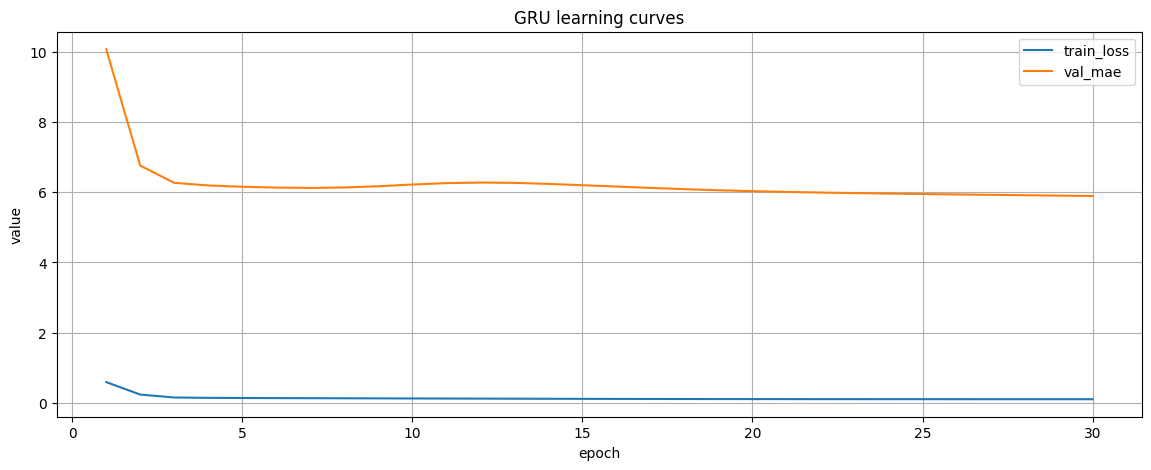

График сохранён: artifacts\figures\gru_learning_curves.png


In [30]:
# ШАГ 31. Сохраняем график кривых обучения GRU
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(14, 5))
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["val_mae"], label="val_mae")
plt.title("GRU learning curves")
plt.xlabel("epoch")
plt.ylabel("value")
plt.legend()
plt.grid(True)

gru_curve_path = FIGURES_DIR / "gru_learning_curves.png"
plt.savefig(gru_curve_path, bbox_inches="tight")
plt.show()

print("График сохранён:", gru_curve_path)

In [31]:
# ШАГ 32. Загружаем лучшую GRU и считаем validation-метрики
best_gru_model = GRURegressor(
    input_size=1,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=0.0
).to(DEVICE)

best_gru_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

metrics_r1_val, val_pred_r1, val_true_r1 = evaluate_model(best_gru_model, val_loader, target_scaler, DEVICE)
print("R1 validation metrics:", metrics_r1_val)

add_run(
    experiment_id="R1",
    task="forecasting",
    dataset="S12-hw-dataset.csv",
    seed=SEED,
    split_summary="70/15/15 temporal split",
    window_size=WINDOW_SIZE,
    horizon=1,
    model_summary=f"GRU(hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS})",
    features_summary="windowed target only",
    scaler="StandardScaler fitted on train target only",
    optimizer="Adam",
    lr=LR,
    epochs_trained=best_epoch,
    best_val_mae=metrics_r1_val["mae"],
    best_val_rmse=metrics_r1_val["rmse"],
    best_val_mape=metrics_r1_val["mape"],
    test_mae="",
    test_rmse="",
    test_mape="",
    notes="Validation only, best checkpoint saved"
)

R1 validation metrics: {'mae': 5.891458988189697, 'rmse': 7.532263723188023, 'mape': np.float32(3.962969), 'smape': np.float32(3.9960313)}


In [32]:
# ШАГ 33. Смотрим результаты validation по всем экспериментам
runs_df = pd.DataFrame(runs)
display(runs_df[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape"]])

,experiment_id,best_val_mae,best_val_rmse,best_val_mape
0,B1,6.443406,8.203532,4.394594
1,B2,12.723717,15.236326,8.828779
2,B3,6.341245,7.935199,4.245655
3,R1,5.891459,7.532264,3.962969


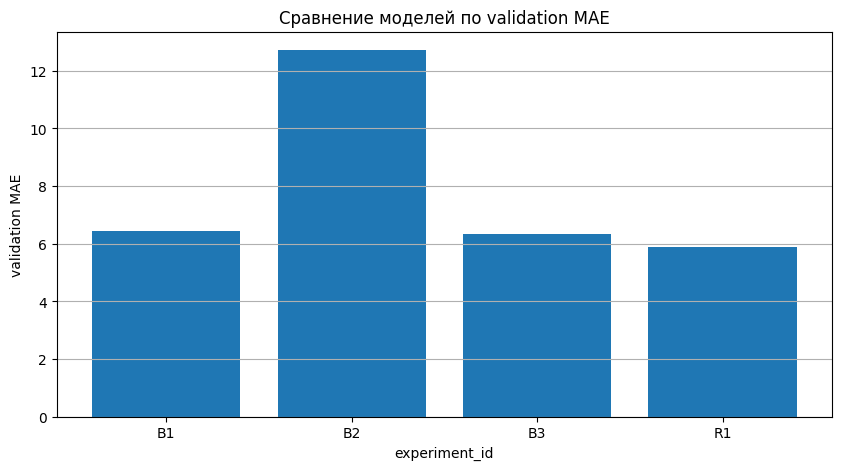

График сохранён: artifacts\figures\baselines_compare.png


In [33]:
# ШАГ 34. Строим сравнение подходов по validation MAE
plot_df = runs_df.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["experiment_id"], plot_df["best_val_mae"])
plt.title("Сравнение моделей по validation MAE")
plt.xlabel("experiment_id")
plt.ylabel("validation MAE")
plt.grid(axis="y")

compare_fig_path = FIGURES_DIR / "baselines_compare.png"
plt.savefig(compare_fig_path, bbox_inches="tight")
plt.show()

print("График сохранён:", compare_fig_path)

In [34]:
# ШАГ 35. Выбираем лучшую модель по validation MAE
best_row = runs_df.loc[runs_df["best_val_mae"].astype(float).idxmin()]
best_experiment_id = best_row["experiment_id"]

print("Лучшая модель по validation MAE:", best_experiment_id)
display(best_row)

Лучшая модель по validation MAE: R1


experiment_id                                               R1
task                                               forecasting
dataset                                     S12-hw-dataset.csv
seed                                                        42
split_summary                          70/15/15 temporal split
window_size                                                 14
horizon                                                      1
model_summary                GRU(hidden_size=32, num_layers=1)
features_summary                          windowed target only
scaler              StandardScaler fitted on train target only
optimizer                                                 Adam
lr                                                       0.001
epochs_trained                                              30
best_val_mae                                          5.891459
best_val_rmse                                         7.532264
best_val_mape                                         3

In [35]:
# ШАГ 36. Финальная оценка лучшей модели на test
best_test_metrics = None
best_test_preds = None
best_test_true = None

if best_experiment_id == "B1":
    test_pred = test_feat["lag_1"].values
    test_true = test_feat["target"].values
    best_test_metrics = calc_metrics(test_true, test_pred)
    best_test_preds = test_pred
    best_test_true = test_true

elif best_experiment_id == "B2":
    test_pred = test_feat["rolling_mean_7"].values
    test_true = test_feat["target"].values
    best_test_metrics = calc_metrics(test_true, test_pred)
    best_test_preds = test_pred
    best_test_true = test_true

elif best_experiment_id == "B3":
    test_pred = ridge_model.predict(X_test_scaled)
    test_true = y_test.values
    best_test_metrics = calc_metrics(test_true, test_pred)
    best_test_preds = test_pred
    best_test_true = test_true

elif best_experiment_id == "R1":
    best_test_metrics, best_test_preds, best_test_true = evaluate_model(best_gru_model, test_loader, target_scaler, DEVICE)

print("Итоговые test-метрики лучшей модели:")
print(best_test_metrics)

Итоговые test-метрики лучшей модели:
{'mae': 6.889394283294678, 'rmse': 8.67680479948237, 'mape': np.float32(4.4421067), 'smape': np.float32(4.5082374)}


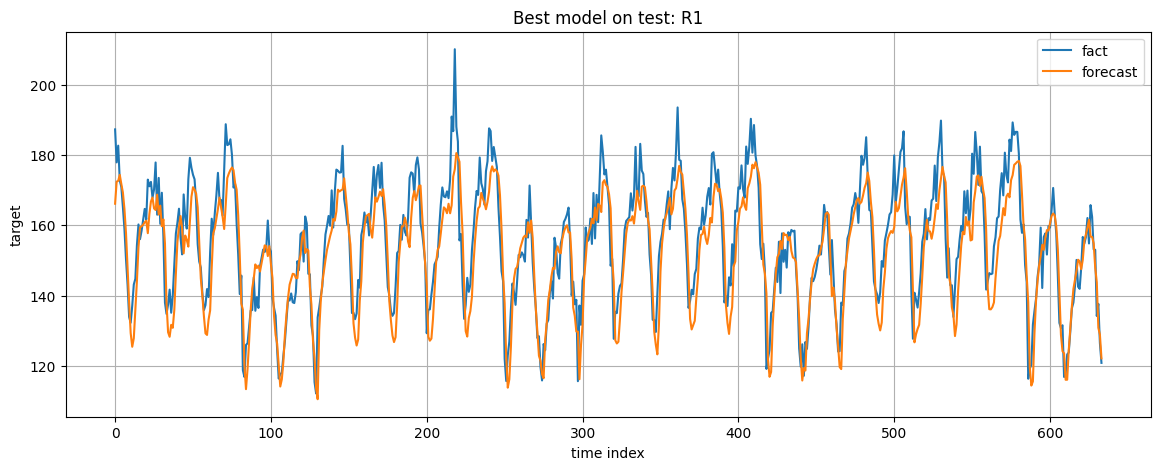

График сохранён: artifacts\figures\best_forecast_test.png


In [36]:
# ШАГ 37. Сохраняем график fact vs forecast для лучшей модели на test
plt.figure(figsize=(14, 5))
plt.plot(best_test_true, label="fact")
plt.plot(best_test_preds, label="forecast")
plt.title(f"Best model on test: {best_experiment_id}")
plt.xlabel("time index")
plt.ylabel("target")
plt.legend()
plt.grid(True)

forecast_fig_path = FIGURES_DIR / "best_forecast_test.png"
plt.savefig(forecast_fig_path, bbox_inches="tight")
plt.show()

print("График сохранён:", forecast_fig_path)

In [38]:
# ШАГ 38. Записываем test-метрики только для лучшего подхода
runs_df = pd.DataFrame(runs)

for col in ["test_mae", "test_rmse", "test_mape"]:
    runs_df[col] = pd.to_numeric(runs_df[col], errors="coerce")

mask = runs_df["experiment_id"] == best_experiment_id
runs_df.loc[mask, "test_mae"] = float(best_test_metrics["mae"])
runs_df.loc[mask, "test_rmse"] = float(best_test_metrics["rmse"])
runs_df.loc[mask, "test_mape"] = float(best_test_metrics["mape"])

runs_csv_path = ARTIFACTS_DIR / "runs.csv"
runs_df.to_csv(runs_csv_path, index=False)

print("runs.csv сохранён:", runs_csv_path)
display(runs_df)

runs.csv сохранён: artifacts\runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,,1,naive-last,last observed value,no,,,,6.443406,8.203532,4.394594,NaN,NaN,NaN,Validation only
1,B2,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,7,1,moving-average,rolling_mean_7,no,,,,12.723717,15.236326,8.828779,NaN,NaN,NaN,Validation only
2,B3,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,,1,Ridge(alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler fitted on train only,,,,6.341245,7.935199,4.245655,NaN,NaN,NaN,Validation only
3,R1,forecasting,S12-hw-dataset.csv,42,70/15/15 temporal split,14,1,"GRU(hidden_size=32, num_layers=1)",windowed target only,StandardScaler fitted on train target only,Adam,0.001,30,5.891459,7.532264,3.962969,6.889394,8.676805,4.442107,"Validation only, best checkpoint saved"


## Краткие выводы

- Для временных рядов обязательно использовать temporal split, а не random split.
- Простые baseline-модели дают важную точку отсчёта и могут оказаться довольно сильными.
- Лаговые и rolling-признаки позволяют табличной модели учитывать локальную динамику ряда.
- GRU работает через оконное представление последовательности и позволяет моделировать временную зависимость напрямую.
- Лучшую модель нужно выбирать по validation, а test использовать только один раз для финальной оценки.